In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

In [9]:
housing=fetch_california_housing()
housing_df=pd.DataFrame(housing.data,columns=housing.feature_names)
# print(housing_df.head())
# print(housing_df.info())
print(housing_df.describe())
# print(housing_df.isnull().sum())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704  
std       10.386050      2.135952      2.003532  
min        0.692308     32.540000   -124.350000  
25%        2.429741     33.930000   -1

In [10]:
print(housing_df.head())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [11]:
housing_df['MedHouseVal'] = housing.target
print(housing_df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [12]:
housing_df['AgeGroup'] = pd.cut(housing_df['HouseAge'], bins=[0, 15, 35, 52], labels=['New', 'Old', 'Historic'])
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,AgeGroup
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,Historic
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,Old
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,Historic
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,Historic
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,Historic
...,...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781,Old
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771,Old
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923,Old
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847,Old


In [13]:
print(housing_df['AgeGroup'].value_counts())

AgeGroup
Old         11009
Historic     6344
New          3287
Name: count, dtype: int64


In [14]:
print(housing_df['AgeGroup'].value_counts(normalize=True) * 100)

AgeGroup
Old         53.338178
Historic    30.736434
New         15.925388
Name: proportion, dtype: float64


/var/folders/w4/p5z5dkzn2jzb_y46x2y01r900000gp/T/ipykernel_25449/43139438.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=housing_df, x='AgeGroup', palette='magma')


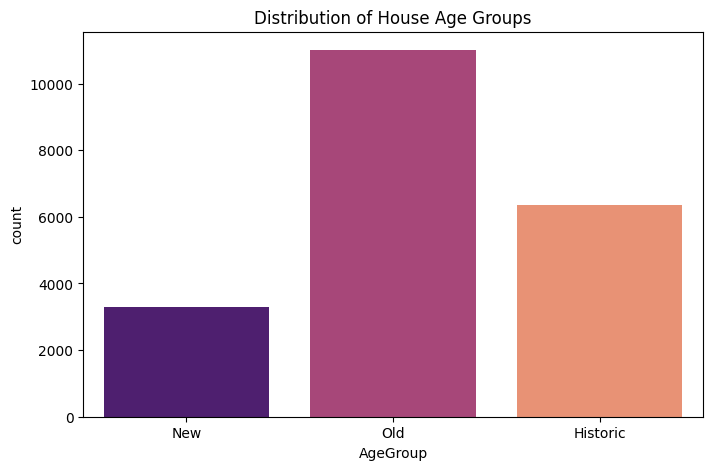

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=housing_df, x='AgeGroup', palette='magma')
plt.title('Distribution of House Age Groups')
plt.show()

Mean: 3.8707
Median: 3.5348
Mode: 3.1250
Std Dev: 1.8998
Variance: 3.6093


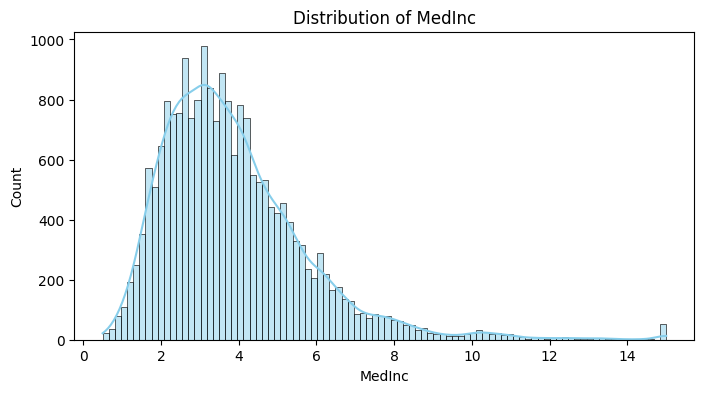

In [16]:
target_col = 'MedInc'

stats = {
    "Mean": housing_df[target_col].mean(),
    "Median": housing_df[target_col].median(),
    "Mode": housing_df[target_col].mode()[0],
    "Std Dev": housing_df[target_col].std(),
    "Variance": housing_df[target_col].var()
}

for key, value in stats.items():
    print(f"{key}: {value:.4f}")

plt.figure(figsize=(8, 4))
sns.histplot(housing_df[target_col], kde=True, color='skyblue')
plt.title(f'Distribution of {target_col}')
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

X = housing_df.drop(columns=['MedHouseVal', 'AgeGroup'])
y = housing_df['MedHouseVal']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# print(f"MSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(model.summary())








AttributeError: 'LinearRegression' object has no attribute 'summary'

In [20]:
# Intercept
print(f"Intercept: {model.intercept_:.4f}")

# Coefficients per feature
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature:>12}: {coef:.4f}")



Intercept: -37.0233
      MedInc: 0.4487
    HouseAge: 0.0097
    AveRooms: -0.1233
   AveBedrms: 0.7831
  Population: -0.0000
    AveOccup: -0.0035
    Latitude: -0.4198
   Longitude: -0.4337


In [2]:
import pandas as pd
import os
dataFrame=pd.read_csv('/Users/rakumar2601/Documents/s3_file_list.txt',sep='\s+', header=None, names=['Date', 'Time', 'Size', 'FullPath'])
dataFrame['LastModified'] = pd.to_datetime(dataFrame['Date'] + ' ' + dataFrame['Time'])
dataFrame['FileName'] = dataFrame['FullPath'].apply(lambda x: os.path.basename(x))

latest_df = dataFrame.sort_values('LastModified', ascending=False).groupby('FileName').first().reset_index()
output_path = '/Users/rakumar2601/Desktop/latest_s3_models.csv'
latest_df.to_csv(output_path, index=False)
print("File saved!!!")




<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/var/folders/w4/p5z5dkzn2jzb_y46x2y01r900000gp/T/ipykernel_35751/4057465004.py:3: SyntaxWarning: invalid escape sequence '\s'
  dataFrame=pd.read_csv('/Users/rakumar2601/Documents/s3_file_list.txt',sep='\s+', header=None, names=['Date', 'Time', 'Size', 'FullPath'])


File saved!!!


In [4]:
filtered_df = latest_df[
    latest_df['FileName'].str.endswith('recode.xml') &
    latest_df['FullPath'].str.contains('visualdna', case=False)
]
output_path_filtered = '/Users/rakumar2601/Documents/latest_s3_recode_files.csv'
filtered_df.to_csv(output_path_filtered, index=False)
print("Filtered file saved!!!")


Filtered file saved!!!


In [10]:
# Linear Regression 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [ ]:
xx = np.array([-0.51, 51.2])
yy = np.array([0.33, 51.6])
means = [xx.mean(), yy.mean()]  
stds = [xx.std() / 3, yy.std() / 3]
corr = 0.8         # correlation
covs = [[stds[0]**2          , stds[0]*stds[1]*corr], 
        [stds[0]*stds[1]*corr,           stds[1]**2]] 

m = np.random.multivariate_normal(means, covs, 1000).T


array([[15.71758586, 36.28615561, 30.22261723, ..., 16.44909363,
        28.10879614, 27.40539345],
       [15.90207289, 33.51883933, 34.55154913, ..., 16.55688016,
        29.69825747, 40.56678811]], shape=(2, 1000))

In [26]:
df=pd.DataFrame()
df['exp(in months)']=m[0]
df['salary(in thousands)']=m[1]
df

,exp(in months),salary(in thousands)
0,15.717586,15.902073
1,36.286156,33.518839
2,30.222617,34.551549
3,33.376818,33.148757
4,26.885965,20.602667
...,...,...
995,17.288389,29.114196
996,28.693650,28.008343
997,16.449094,16.556880
998,28.108796,29.698257


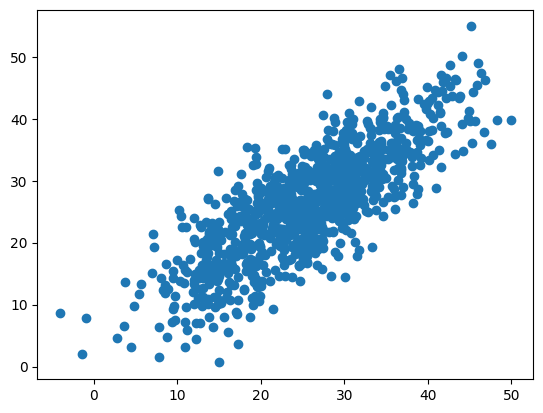

In [27]:
plt.scatter(df['exp(in months)'],df['salary(in thousands)'])

In [28]:
X=df.iloc[:,1:2]
Y=df.iloc[:, -1]
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

In [33]:
lr=LinearRegression()
lr.fit(X_train,Y_train)
# print(X_test)
# print(Y_test)
Y_pred = lr.predict(X_test.iloc[1].values.reshape(1,1))
print(Y_pred)


[15.83899094]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [36]:
# Finding the Coefs and intercept

# Equation of line is given by y=mx+b
# y=0.81*x + 5.50
# m ---> slope
# b ---> intercept

# X coefficient
print(lr.coef_[0])

# Y intercept
print(lr.intercept_)

0.9999999999999994
1.4210854715202004e-14
